In [2]:
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_csv("imdb_top_1000.csv")

print(df.head(10))
print("---------------------------")
print(df.info())
print("---------------------------")


   Rank                    Title                       Genre  \
0     1  Guardians of the Galaxy     Action,Adventure,Sci-Fi   
1     2               Prometheus    Adventure,Mystery,Sci-Fi   
2     3                    Split             Horror,Thriller   
3     4                     Sing     Animation,Comedy,Family   
4     5            Suicide Squad    Action,Adventure,Fantasy   
5     6           The Great Wall    Action,Adventure,Fantasy   
6     7               La La Land          Comedy,Drama,Music   
7     8                 Mindhorn                      Comedy   
8     9       The Lost City of Z  Action,Adventure,Biography   
9    10               Passengers     Adventure,Drama,Romance   

                                         Description              Director  \
0  A group of intergalactic criminals are forced ...            James Gunn   
1  Following clues to the origin of mankind, a te...          Ridley Scott   
2  Three girls are kidnapped by a man with a diag...    M. Ni

3. summarizes each category for count, mean, std, min, 25th percentile, 50th percentile, 75th percentile, and the max of each column in the csv file.

In [3]:
##4
summary = df.describe()
print(summary)

              Rank         Year  Runtime (Minutes)       Rating         Votes  \
count  1000.000000  1000.000000        1000.000000  1000.000000  1.000000e+03   
mean    500.500000  2012.783000         113.172000     6.723200  1.698083e+05   
std     288.819436     3.205962          18.810908     0.945429  1.887626e+05   
min       1.000000  2006.000000          66.000000     1.900000  6.100000e+01   
25%     250.750000  2010.000000         100.000000     6.200000  3.630900e+04   
50%     500.500000  2014.000000         111.000000     6.800000  1.107990e+05   
75%     750.250000  2016.000000         123.000000     7.400000  2.399098e+05   
max    1000.000000  2016.000000         191.000000     9.000000  1.791916e+06   

       Revenue (Millions)   Metascore  
count          872.000000  936.000000  
mean            82.956376   58.985043  
std            103.253540   17.194757  
min              0.000000   11.000000  
25%             13.270000   47.000000  
50%             47.985000   59

summarizes: rank, tear, runtime, rating, votes, revenue, and metascore

array([[<Axes: title={'center': 'Rank'}>,
        <Axes: title={'center': 'Year'}>,
        <Axes: title={'center': 'Runtime (Minutes)'}>],
       [<Axes: title={'center': 'Rating'}>,
        <Axes: title={'center': 'Votes'}>,
        <Axes: title={'center': 'Revenue (Millions)'}>],
       [<Axes: title={'center': 'Metascore'}>, <Axes: >, <Axes: >]],
      dtype=object)

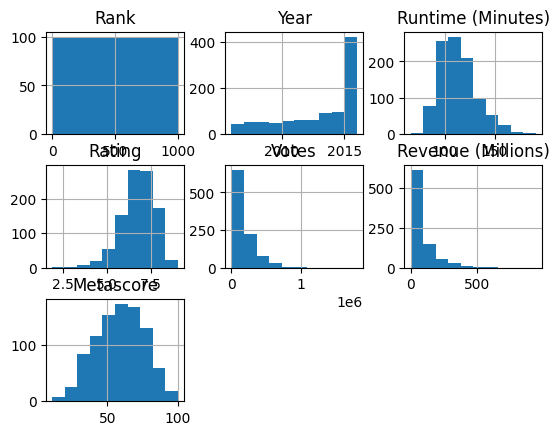

In [4]:
df.hist(bins=10)

what can we observe fr3om the historgraams? are runtimes clustered around a range? 

rank graph not super helpful; have to check the columns
runtimes are clustered yes. STD is low. 

In [5]:
#variance
hello = df['Rating'].var()
print(hello)

0.8938355955955956


In [6]:
hi = df['Rating'].sort_values()
print(hi.tail(10))

991    8.5
99     8.5
124    8.5
133    8.5
96     8.6
36     8.6
249    8.6
117    8.8
80     8.8
54     9.0
Name: Rating, dtype: float64


In [11]:
count = 0
for i in df['Rating']:
    if i > 8.5:
        print(i)
        count += 1
print(f'there are {count} numbers that are greater than 8.5')

8.6
9.0
8.8
8.6
8.8
8.6
there are 6 numbers that are greater than 8.5


In [15]:
darshan = df.corr()
print(darshan)
# not sure how to do this one

SyntaxError: expression cannot contain assignment, perhaps you meant "=="? (1984275330.py, line 1)

In [21]:
# Filtering using multiple conditions: filter the DataFrame to show only movies with Rating > 8.0
# AND Runtime < 100. Why might these shorter high-rated movies be worth investigating?

filtered_df = df[(df['Rating'] > 8.0) & (df["Runtime (Minutes)"] < 100)]
print(filtered_df)

# not sure exaclt ywhy it'd be important to investigate these ones. 

     Rank                           Title                       Genre  \
154   155  Twin Peaks: The Missing Pieces        Drama,Horror,Mystery   
238   239        The Grand Budapest Hotel      Adventure,Comedy,Drama   
241   242                      Inside Out  Animation,Adventure,Comedy   
478   479                  Paint It Black                       Drama   
499   500                              Up  Animation,Adventure,Comedy   
634   635                          WALL·E  Animation,Adventure,Family   
695   696             Hachi: A Dog's Tale                Drama,Family   
772   773        How to Train Your Dragon  Animation,Action,Adventure   

                                           Description         Director  \
154  Twin Peaks before Twin Peaks (1990) and at the...      David Lynch   
238  The adventures of Gustave H, a legendary conci...     Wes Anderson   
241  After young Riley is uprooted from her Midwest...      Pete Docter   
478  A young woman attempts to deal with t

15) Boxplots are useful for spotting outliers (points much higher or lower than the typical range). Plot
a boxplot of the "IMDB_Rating" column using matplotlib. Are there any noticeable outliers?
Where are most ratings centered?

{'whiskers': [<matplotlib.lines.Line2D at 0x1229657f0>,
 'caps': [<matplotlib.lines.Line2D at 0x122965a90>,
 'boxes': [<matplotlib.lines.Line2D at 0x1229656a0>],
 'medians': [<matplotlib.lines.Line2D at 0x122965d30>],
 'fliers': [<matplotlib.lines.Line2D at 0x122965e80>],
 'means': []}

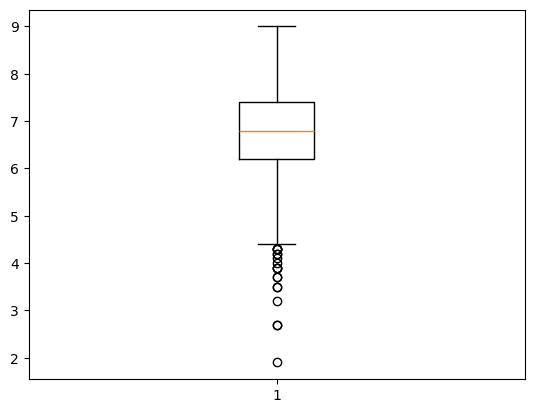

In [30]:
plt.boxplot(df["Rating"])

Ratings by genre: Group-by is a powerful method in Pandas. It allows you to group rows by a
category (like Genre), then compute summary stats for each group. Group the DataFrame by
"Genre" and calculate the average IMDB_Rating per genre. Which genre has the highest average
rating?

In [45]:
a = df.groupby('Genre')
print(a)
# how does one do this? I am so confused ms patel....

# Real-world data is often messy. First, let’s check for missing values and then decide what to do.
Use df.isnull().sum() to count missing values per column. Drop any rows that contain missing
data. How many rows remain?

In [50]:
df.isnull().sum()
# not sure how to clear it

Rank                    0
Title                   0
Genre                   0
Description             0
Director                0
Actors                  0
Year                    0
Runtime (Minutes)       0
Rating                  0
Votes                   0
Revenue (Millions)    128
Metascore              64
dtype: int64

Grouping by year: Let’s examine how movie ratings have changed over time. Group the data by
"Released_Year" and calculate average "IMDB_Rating" per year. Plot a line chart of average
rating by year. What trend do you see?